In [12]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from langchain_core.messages import BaseMessage,HumanMessage,SystemMessage
import os
from dotenv import load_dotenv
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.tools import tool
from langgraph.graph.message import add_messages 
from langchain_mistralai import MistralAIEmbeddings,ChatMistralAI
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.prebuilt import ToolNode,tools_condition
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.tools import DuckDuckGoSearchRun
import requests
# import operator

In [2]:
load_dotenv()
os.environ['MISTRAL_API_KEY'] = os.getenv('MISTRAL_API_KEY')

llm = ChatMistralAI(model='mistral-large-latest',temperature=0)

In [ ]:
# 1. load the document 
loader = PyPDFLoader('../data/attention.pdf')
docs = loader.load()

In [4]:
len(docs)

15

In [5]:
# 2. Chunking --> Text splitters
splitter = RecursiveCharacterTextSplitter(chunk_size = 1000, chunk_overlap = 200)
chunks = splitter.split_documents(docs)

In [6]:
len(chunks)

52

In [7]:
# 3. Embedding and store in Vector store

embeddings = MistralAIEmbeddings(model = 'mistral-embed')
vector_store = FAISS.from_documents(chunks,embedding=embeddings)

In [8]:
vector_store

In [9]:
retriever = vector_store.as_retriever(search_type = 'similarity',search_kwargs = {'k':4})

In [10]:
retriever.invoke('what is an Encoder?')

[Document(id='e706ff9e-a9bc-442c-b4b5-12fbfad25f42', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaTeX with hyperref', 'creationdate': '2024-04-10T21:11:43+00:00', 'author': '', 'keywords': '', 'moddate': '2024-04-10T21:11:43+00:00', 'ptex.fullbanner': 'This is pdfTeX, Version 3.141592653-2.6-1.40.25 (TeX Live 2023) kpathsea version 6.3.5', 'subject': '', 'title': '', 'trapped': '/False', 'source': '../data/attention.pdf', 'total_pages': 15, 'page': 1, 'page_label': '2'}, page_content='Here, the encoder maps an input sequence of symbol representations (x1, ..., xn) to a sequence\nof continuous representations z = (z1, ..., zn). Given z, the decoder then generates an output\nsequence (y1, ..., ym) of symbols one element at a time. At each step the model is auto-regressive\n[10], consuming the previously generated symbols as additional input when generating the next.\n2'),
 Document(id='b65b1b38-bae5-4599-9a32-981f6711cc71', metadata={'producer': 'pdfTeX-1.40.25', 'creator': 'LaT

In [13]:
# Wrap the RAG with Tool
@tool
def rag_tool(query):
    """
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored documents
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]
    
    return {
        'query':query,
        'context':context,
        'metadata':metadata
    }

In [14]:
#Tools
search_tool  = DuckDuckGoSearchRun(region = "us-en")

@tool 
def calculator(first_num : float,second_num : float , operation:str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers
    Supported operations: add , sub, mul , div
    """
    operation = operation.lower()
    try:
        if operation == 'add':
            result = first_num + second_num
        elif operation == 'sub':
            result = first_num - second_num
        elif operation == 'mul':
            result = first_num * second_num
        elif operation == 'div':
            if second_num == 0:
                return {"error":"Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error":f"Unsupported operation,{operation}"}
        return {"first_num":first_num,"second_num":second_num,"operation":operation,"result":result}
    except Exception as e:
        return {'error':str(e)}
    
@tool
def get_stock_price(symbol:str)->dict:
    """
    Fetch latest stock price for a given symbol (eg:'AAPL','TSLA')
    using Alpha Vantage with API key in the URL.
    """
    api_key = os.getenv('ALPHA_VANTAGE_API_KEY')
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey={api_key}"
    r = requests.get(url)
    return r.json()
        

In [15]:
tools = [rag_tool,search_tool,calculator,get_stock_price]
llm_with_tools = llm.bind_tools(tools)

In [16]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [17]:
def chat_node(state:ChatState)-> ChatState:
    messages = state['messages']
    response = llm_with_tools.invoke(messages)

    return {'messages':[response]}

In [18]:
tool_node = ToolNode(tools)

In [ ]:
# build the graph
check_pointer = MemorySaver()
graph = StateGraph(ChatState)

graph.add_node('chat_node',chat_node)
graph.add_node('tools',tool_node)

graph.add_edge(START,'chat_node')
graph.add_conditional_edges('chat_node',tools_condition)
graph.add_edge('tools','chat_node')

chat_bot = graph.compile(checkpointer=check_pointer)


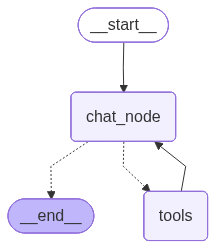

In [20]:
chat_bot

In [22]:
result = chat_bot.invoke(
    {
        'messages':[
            HumanMessage(
                content=(   
                    "Using the pdf notes , explain what is a Transformer , and its working"
                )
            )
        ]
    }
)

In [23]:
print(result['messages'][-1].content)

### **What is a Transformer?**
The **Transformer** is a groundbreaking deep learning model architecture introduced in the paper *"Attention Is All You Need"* (Vaswani et al., 2017). It revolutionized the field of natural language processing (NLP) and other sequence-based tasks by **eliminating the need for recurrent neural networks (RNNs) or convolutional neural networks (CNNs)**. Instead, it relies entirely on **self-attention mechanisms** to capture relationships between words or tokens in a sequence, enabling parallelization and significantly improving training efficiency.

---

### **Key Features of the Transformer**
1. **No Recurrence or Convolution**:
   - Unlike RNNs (e.g., LSTMs, GRUs) or CNNs, the Transformer does not process data sequentially. This allows for **massive parallelization**, making it faster to train.
   - It captures long-range dependencies in data without the vanishing gradient problem common in RNNs.

2. **Self-Attention Mechanism**:
   - The core innovation o

In [26]:
thread_id = '1'
while True:
    user_message = input("Type here:")
    
    print(f"Me : {user_message}")

    if user_message.strip().lower() in ['exit','quit','stop','bye']:
        print("AI : Thanks for chatting with me! Have a great day 👋")
        break

    
    try:
        print('Thinking....')
        config = {
            'configurable':{
                'thread_id':thread_id
            }
        }

        response = chat_bot.invoke({'messages':[HumanMessage(content=user_message)]}, config=config)
        print(f"AI : {response['messages'][-1].content}")
    except Exception as e:
        print("Error:", e)
    


Me : what is the average cost needed to buy a sunscreen product brand in Goa for a week trip ? give suggestions
Thinking....
AI : Here’s a breakdown of the **average cost of sunscreen products in Goa** for a **week-long trip**, along with suggestions for choosing the right sunscreen:

---

### **Average Cost of Sunscreen in Goa**
1. **Budget Range (Drugstore Brands):**
   - **Price:** ₹200 – ₹500
   - **Examples:** Nivea, Lotus, Lacto Calamine, or local brands.
   - **Quantity:** 50g – 100g tube.
   - **Suitable for:** Daily use, moderate sun exposure.

2. **Mid-Range (Premium Brands):**
   - **Price:** ₹500 – ₹1,200
   - **Examples:** Neutrogena, Biotique, Mamaearth, Aqualogica, or The Derma Co.
   - **Quantity:** 50g – 80g tube.
   - **Suitable for:** Sensitive skin, extended sun exposure, or beach activities.

3. **High-End (Luxury/International Brands):**
   - **Price:** ₹1,200 – ₹3,000+
   - **Examples:** La Roche-Posay, Clinique, Supergoop!, or Innisfree.
   - **Quantity:** 30g –

In [ ]:
import os

load_dotenv()

print(os.getenv("GOOGLE_API_KEY"))
print(os.getenv("LANGSMITH_API_KEY"))
print(os.getenv("LANGSMITH_TRACING"))
print(os.getenv("LANGSMITH_PROJECT"))